In [ ]:
# මුලින්ම පැකේජ් එක install කරමු
%pip install nltk

# මුලින්ම මේ ටික විතරක් රන් කරපන්
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# දැන් NLTK ටික වෙනම load කරමු
import nltk
print(f"NLTK version: {nltk.__version__}") # මෙතනදී module එක load වෙනවා

# දැන් අනිත් ටික
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# අත්‍යවශ්‍ය දත්ත ටික download කරමු
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

print("Libraries loaded successfully! ✅")

NLTK version: 3.9.1


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Libraries loaded successfully! ✅


[nltk_data] Downloading package wordnet to /root/nltk_data...


  label                                               text  label_num
0   ham  Subject: enron methanol ; meter # : 988291\r\n...          0
1   ham  Subject: hpl nom for january 9 , 2001\r\n( see...          0
2   ham  Subject: neon retreat\r\nho ho ho , we ' re ar...          0
3  spam  Subject: photoshop , windows , office . cheap ...          1
4   ham  Subject: re : indian springs\r\nthis deal is t...          0


/tmp/ipykernel_11572/4166047323.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='viridis')


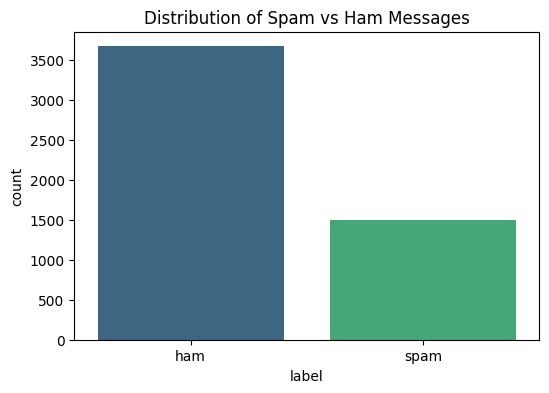

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5171 entries, 0 to 5170
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   label      5171 non-null   object
 1   text       5171 non-null   object
 2   label_num  5171 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 121.3+ KB
None


In [2]:
# Dataset එක load කිරීම (ඔයා CSV එක Google Colab එකට Upload කරලා තියෙන්න ඕනේ)
df = pd.read_csv('spam_ham_dataset.csv')

# අනවශ්‍ය Columns අයින් කරමු (උදාහරණයක් විදිහට 'Unnamed: 0' තිබුණොත්)
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

# දත්ත වල මුල් පේළි කිහිපය පරීක්ෂා කිරීම
print(df.head())

# Spam vs Ham ප්‍රමාණය Graph එකකින් බලමු (EDA Report එකට මේක ඕනේ)
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='label', palette='viridis')
plt.title('Distribution of Spam vs Ham Messages')
plt.show()

# ඩේටා වල තොරතුරු බලමු (null values තියෙනවද කියලා බලන්න)
print(df.info())

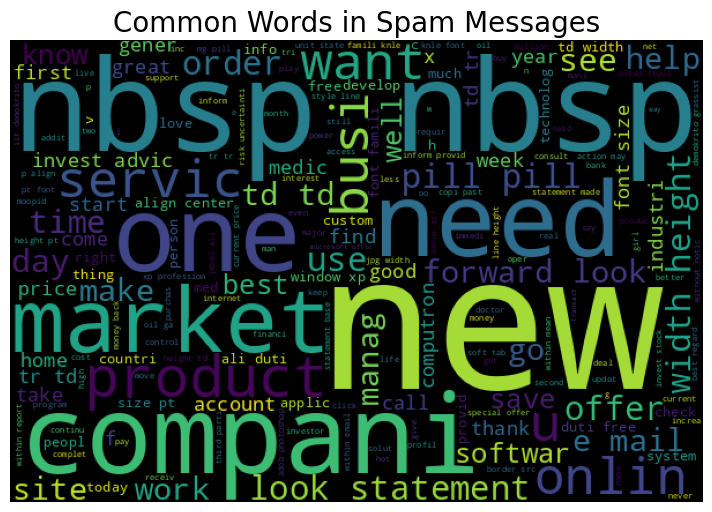

/tmp/ipykernel_11572/808354124.py:17: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['label_num'] == 0]['char_count'], shade=True, label='Ham', color='blue')
/tmp/ipykernel_11572/808354124.py:18: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['label_num'] == 1]['char_count'], shade=True, label='Spam', color='red')


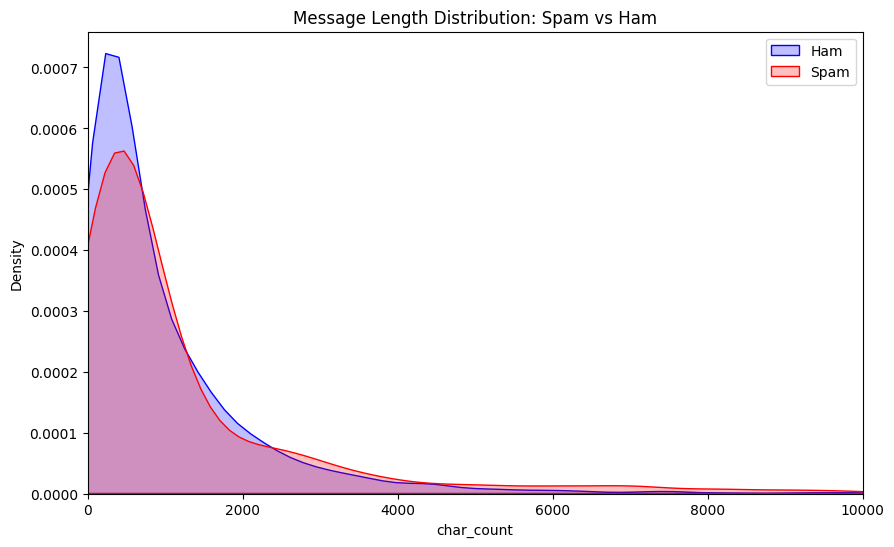

In [7]:
from wordcloud import WordCloud

# 1. Spam මැසේජ් වල වැඩිපුරම තියෙන වචන බලමු (Word Cloud)
spam_words = ' '.join(list(df[df['label_num'] == 1]['cleaned_text']))
spam_wc = WordCloud(width=600, height=400, background_color='black').generate(spam_words)

plt.figure(figsize=(10, 6))
plt.imshow(spam_wc)
plt.axis('off')
plt.title('Common Words in Spam Messages', fontsize=20)
plt.show()

# 2. මැසේජ් එකක දිග (Length) අනුව බෙදී යන හැටි
df['char_count'] = df['text'].apply(len)

plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['label_num'] == 0]['char_count'], shade=True, label='Ham', color='blue')
sns.kdeplot(df[df['label_num'] == 1]['char_count'], shade=True, label='Spam', color='red')
plt.title('Message Length Distribution: Spam vs Ham')
plt.legend()
plt.xlim(0, 10000) # ගොඩක් දිග ඒවා අයින් කරලා ලස්සනට බලමු
plt.show()

/tmp/ipykernel_11572/3849705171.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=y, y=x, palette='rocket')


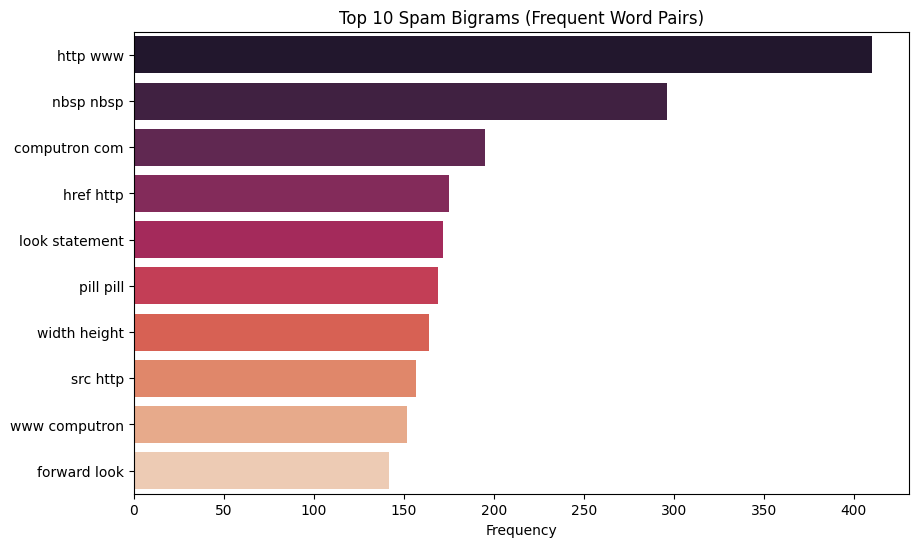

In [8]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_n_bigrams(corpus, n=None):
    vec = CountVectorizer(ngram_range=(2, 2), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

# Spam මැසේජ් වල තියෙන වචන දෙකේ ජෝඩු ගමු
top_bigrams = get_top_n_bigrams(df[df['label_num'] == 1]['cleaned_text'], n=10)
x, y = map(list, zip(*top_bigrams))

plt.figure(figsize=(10,6))
sns.barplot(x=y, y=x, palette='rocket')
plt.title('Top 10 Spam Bigrams (Frequent Word Pairs)')
plt.xlabel('Frequency')
plt.show()

In [3]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re

# Stemmer එකක් හදාගනිමු (වචන වල මූලික අවස්ථාවට ගන්න)
ps = PorterStemmer()

def clean_text(text):
    # 1. 'Subject:' කියන එක අයින් කරමු
    text = re.sub(r'^Subject: ', '', text)

    # 2. අකුරු නොවන දේවල් (ලකුණු, ඉලක්කම්) අයින් කරමු
    text = re.sub('[^a-zA-Z]', ' ', text)

    # 3. ඔක්කොම පොඩි අකුරු (Lower case) කරමු
    text = text.lower()

    # 4. වචන වලට කඩමු (Tokenization)
    words = text.split()

    # 5. Stopwords (is, the, a...) අයින් කරලා Stemming කරමු
    cleaned_words = [ps.stem(w) for w in words if w not in set(stopwords.words('english'))]

    # 6. ආයෙත් මැසේජ් එකක් විදිහට පේළියට හදමු
    return ' '.join(cleaned_words)

# අලුත් column එකකට ක්ලීන් කරපු ටෙක්ස්ට් එක දාමු
print("Cleaning process started... ⏳")
df['cleaned_text'] = df['text'].apply(clean_text)

# ප්‍රතිඵලය චෙක් කරලා බලමු
print("\n--- පිරිසිදු කිරීමට පෙර ---")
print(df['text'].iloc[3][:150] + "...") # Spam එකක් බලමු

print("\n--- පිරිසිදු කිරීමෙන් පසු ---")
print(df['cleaned_text'].iloc[3][:150] + "...")

print("\nDone! ✅")

Cleaning process started... ⏳

--- පිරිසිදු කිරීමට පෙර ---
Subject: photoshop , windows , office . cheap . main trending
abasements darer prudently fortuitous undergone
lighthearted charm orinoco taster
rai...

--- පිරිසිදු කිරීමෙන් පසු ---
photoshop window offic cheap main trend abas darer prudent fortuit undergon lightheart charm orinoco taster railroad affluent pornograph cuvier irvin ...

Done! ✅


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# 1. TF-IDF Vectorizer එක හදාගමු
# max_features=3000 කියන්නේ වැදගත්ම වචන 3000 විතරක් ගමු කියන එක
tfidf = TfidfVectorizer(max_features=3000)

# 2. පිරිසිදු කරපු text ටික ඉලක්කම් (Matrix) බවට හරවමු
X = tfidf.fit_transform(df['cleaned_text']).toarray()

# 3. අපේ Target එක (Spam ද නැද්ද කියන එක - 0 හෝ 1)
y = df['label_num'].values

# 4. ඩේටා ටික බෙදමු (Train-Test Split)
# 80% ක් මොඩල් එකට උගන්වන්න (Train), 20% ක් පස්සේ චෙක් කරන්න (Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total rows: {len(X)}")
print(f"Train data size: {len(X_train)}")
print(f"Test data size: {len(X_test)}")
print("Vectorization and Splitting Done! ✅")

Total rows: 5171
Train data size: 4136
Test data size: 1035
Vectorization and Splitting Done! ✅


--- Model Performance ---
Accuracy: 94.88%

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       742
           1       0.88      0.94      0.91       293

    accuracy                           0.95      1035
   macro avg       0.93      0.95      0.94      1035
weighted avg       0.95      0.95      0.95      1035



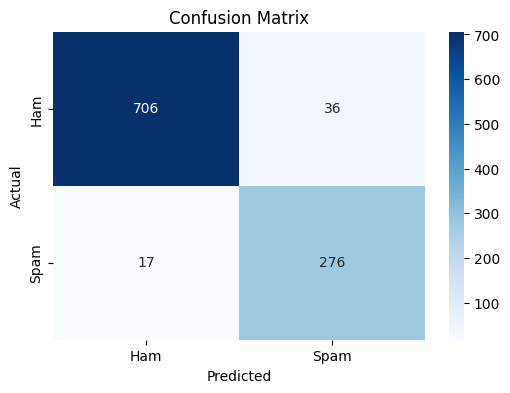

In [5]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

# 1. Naive Bayes Model එක හදමු
model = MultinomialNB()

# 2. මොඩල් එක ට්‍රේන් කරමු (ඉගෙන ගන්න දෙනවා)
model.fit(X_train, y_train)

# 3. දැන් ටෙස්ට් ඩේටා ටික දීලා Predict කරමු
y_pred = model.predict(X_test)

# 4. රිපෝට් එකට අවශ්‍ය Evaluation Metrics බලමු
print("--- Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 5. Confusion Matrix එක ඇඳලා බලමු (මේක රිපෝට් එකට අනිවාර්යයි)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [6]:
import pickle

# 1. මොඩල් එක සහ Vectorizer එක save කරමු
pickle.dump(model, open('spam_model.pkl', 'wb'))
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))

print("Model and Vectorizer saved successfully! ✅")

# 2. දැන් අලුත් message එකක් දීලා බලමු වැඩද කියලා
def predict_spam(sample_message):
    # කලින් කරපු විදිහටම text එක සුද්ද කරන්න ඕනේ
    cleaned_sample = clean_text(sample_message)

    # Vectorizer එක පාවිච්චි කරලා ඉලක්කම් වලට හරවමු
    sample_vector = tfidf.transform([cleaned_sample]).toarray()

    # Prediction එක ගමු
    prediction = model.predict(sample_vector)

    if prediction[0] == 1:
        return "🚨 SPAM ALERT!"
    else:
        return "✅ This is a HAM message."

# ටෙස්ට් කරලා බලමු
test_msg = "Congratulations! You won a $1000 Walmart gift card. Click here to claim now!"
print(f"Message: {test_msg}")
print(f"Result: {predict_spam(test_msg)}")

test_msg_2 = "Hey buddy, are we still meeting for tea today at the lake?"
print(f"\nMessage: {test_msg_2}")
print(f"Result: {predict_spam(test_msg_2)}")

Model and Vectorizer saved successfully! ✅
Message: Congratulations! You won a $1000 Walmart gift card. Click here to claim now!
Result: 🚨 SPAM ALERT!

Message: Hey buddy, are we still meeting for tea today at the lake?
Result: ✅ This is a HAM message.
